In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/industrial-equipment-monitoring-dataset/equipment_anomaly_data.csv


In [2]:
import numpy as np
import pandas as pd
data = pd.read_csv("/kaggle/input/industrial-equipment-monitoring-dataset/equipment_anomaly_data.csv")

In [3]:
data.head()

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


In [4]:
data.tail()

,temperature,pressure,vibration,humidity,equipment,location,faulty
7667,65.711521,37.505934,2.030521,49.331471,Pump,New York,0.0
7668,63.005855,45.164234,1.264585,61.905390,Pump,New York,0.0
7669,72.029230,34.757896,1.709046,49.972917,Pump,Atlanta,0.0
7670,107.086485,23.754114,1.142522,23.967977,Compressor,Atlanta,1.0
7671,28.468054,66.588978,4.677368,79.670225,Turbine,Chicago,1.0


In [5]:
data.shape


(7672, 7)

In [6]:
data.describe()

,temperature,pressure,vibration,humidity,faulty
count,7672.000000,7672.000000,7672.000000,7672.000000,7672.000000
mean,70.922478,35.738048,1.611809,50.016574,0.099974
std,16.200059,10.381593,0.728560,11.841479,0.299985
min,10.269385,3.620798,-0.428188,10.215077,0.000000
25%,62.777057,29.485682,1.170906,42.612817,0.000000
50%,70.156900,35.227544,1.533113,50.024744,0.000000
75%,77.568387,41.159913,1.924700,57.340513,0.000000
max,149.690420,79.887734,4.990537,89.984718,1.000000


In [7]:
data.info()  #null values and dtype if dtype object then do encoding 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty       7672 non-null   float64
dtypes: float64(5), object(2)
memory usage: 419.7+ KB


In [8]:
#encoding , feature scaling , outliers
#encoding
data['location'].unique()

array(['Atlanta', 'Chicago', 'San Francisco', 'New York', 'Houston'],
      dtype=object)

In [9]:
data['equipment'].unique()

array(['Turbine', 'Compressor', 'Pump'], dtype=object)

In [10]:
# from sklearn.preprocessing import LabelEncoder
# LE = LabelEncoder()

In [11]:
#data['location'] = LE.fit_transform(data['location'])

In [12]:
# data['equipment'] = LE.fit_transform(data['equipment'])

In [13]:
 data.info()
#location dtype obj is converted to int
#equipment is also converted to int

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty       7672 non-null   float64
dtypes: float64(5), object(2)
memory usage: 419.7+ KB


In [14]:
#CUSTOM ENCODING
data['location'].unique()


array(['Atlanta', 'Chicago', 'San Francisco', 'New York', 'Houston'],
      dtype=object)

In [15]:
data['location'] = data['location'].map({'Atlanta' : 1 , 'Chicago': 2, 'San Francisco' : 3, 'New York' : 4, 'Houston' : 5})

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   int64  
 6   faulty       7672 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 419.7+ KB


In [17]:
data['equipment'].unique()

array(['Turbine', 'Compressor', 'Pump'], dtype=object)

In [18]:
data['equipment'] = data['equipment'].map({'Turbine': 1, 'Compressor':2, 'Pump':3})

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   int64  
 5   location     7672 non-null   int64  
 6   faulty       7672 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 419.7 KB


In [20]:
data.isnull().sum() #all zero so no imputation needed

temperature    0
pressure       0
vibration      0
humidity       0
equipment      0
location       0
faulty         0
dtype: int64

In [21]:
#Feature Scaling 
from sklearn.preprocessing import StandardScaler, MinMaxScaler , RobustScaler

scaler1 = StandardScaler()
scaler2 = MinMaxScaler()
scaler3 = RobustScaler()

In [22]:
import seaborn as sns


<Axes: xlabel='temperature', ylabel='Density'>

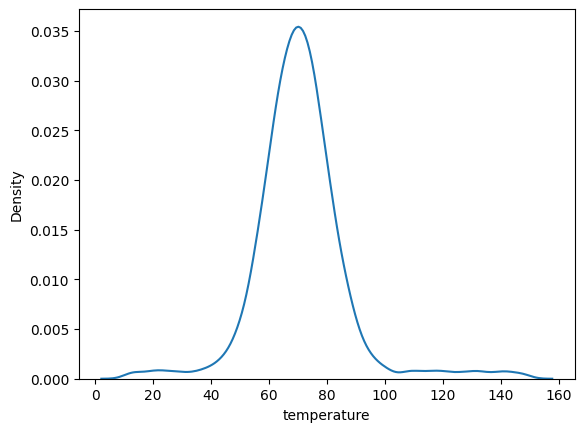

In [23]:
sns.kdeplot(data['temperature'])

In [24]:
dummy1 = scaler1.fit_transform(data[['temperature']])

<Axes: ylabel='Density'>

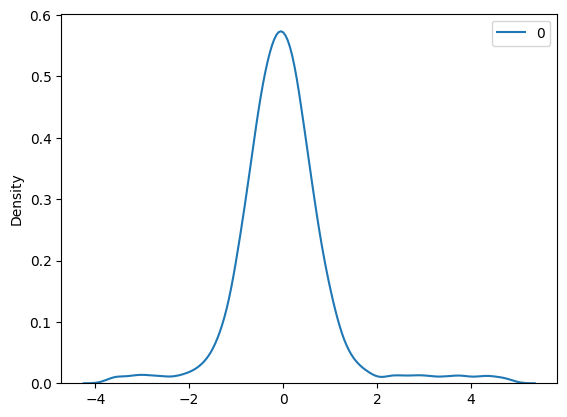

In [25]:
sns.kdeplot(dummy1 )

In [26]:
dummy2 = scaler2.fit_transform(data[['temperature']])

<Axes: ylabel='Density'>

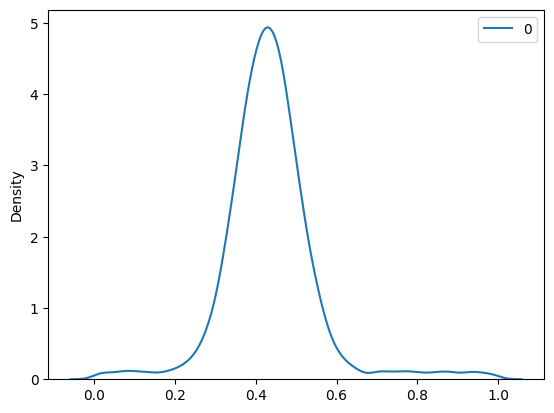

In [27]:
sns.kdeplot(dummy2 )

In [28]:
dummy3 = scaler3.fit_transform(data[['temperature']])

<Axes: ylabel='Density'>

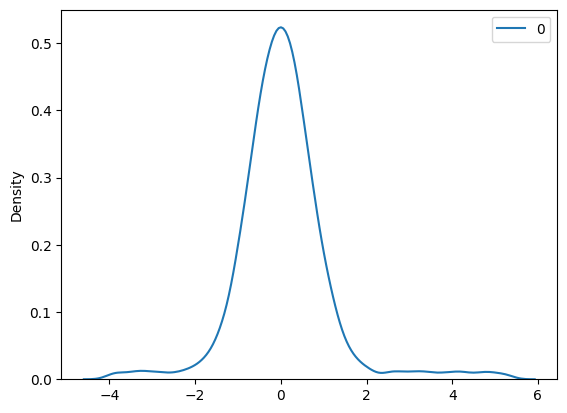

In [29]:
sns.kdeplot(dummy3 )

In [30]:
#train test splitting
from sklearn.model_selection import train_test_split


In [31]:
# Y = data['MEDV']                                
# data.drop('MEDV', axis = 1, inplace=True)
# X = data
# key error aayegi  bchne ke liye ek baar run kro bs firse run kroge toh key error aayegi kyunki medv toh pehle hi remove ho gyi
Y = data['faulty']                                
data.drop('faulty', axis = 1, inplace=True)
X = data

In [32]:
#sequence matters kyunki output ke sath matter krega 
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.8) # 30 % testing me jayega isliye test size is 0.3 aur by default 70% training  , train_size se training data ka size 70% kr skte h 
#agar random state ko fix krna h toh aage ek aur parameter lga do random_state = 42 

In [33]:
X_train.head() #train_test_split random splitting krta h ...

,temperature,pressure,vibration,humidity,equipment,location
7122,53.451433,39.879040,1.027624,50.596619,1,2
2213,65.599555,39.829166,1.220592,41.715919,3,5
2116,70.998870,47.434260,1.667609,63.271286,3,4
2632,67.941406,46.877135,1.531223,58.193469,2,3
4676,76.832230,32.350086,2.145665,37.043717,1,4
